# EDUSign – Real-Time Sign Language Learning System

This notebook covers:
- MediaPipe landmark extraction
- Dataset creation (.npz)
- CNN training (TensorFlow/Keras)
- Evaluation (accuracy + confusion matrix)
- Saving the trained model (.h5)


In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import cv2
import mediapipe as mp
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("OpenCV:", cv2.__version__)
print("MediaPipe:", mp.__version__)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)


OpenCV: 4.13.0
MediaPipe: 0.10.9
TensorFlow: 2.12.0
NumPy: 1.23.5


In [3]:
# CHANGE THIS ONLY IF YOUR EDUSign FOLDER IS IN A DIFFERENT DRIVE/FOLDER
PROJECT_ROOT = r"D:\EDUSign"

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

for p in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(p, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)


PROJECT_ROOT: D:\EDUSign
DATA_PROCESSED: D:\EDUSign\data\processed


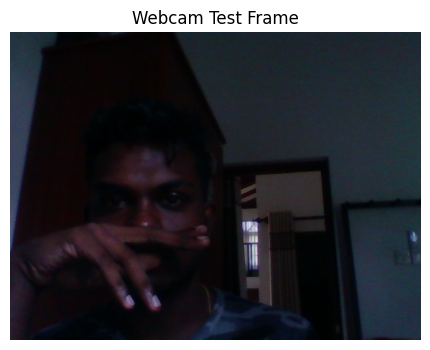

In [4]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("Camera not accessible. Try closing other apps using the camera (Zoom/Teams/etc).")

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Failed to grab a frame from the camera.")

# Show one captured frame
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,4))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Webcam Test Frame")
plt.show()


In [5]:
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
)

print("MediaPipe Hands initialized ✅")


MediaPipe Hands initialized ✅


In [6]:
cap = cv2.VideoCapture(0)
start = time.time()

while time.time() - start < 10:  # run for 10 seconds
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)  # mirror view
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

    cv2.imshow("MediaPipe Hands Test (10 sec)", frame)

    # press q to quit early
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Done ✅")


Done ✅


In [8]:
def extract_hand_landmarks(results):
    """
    Returns a (63,) numpy array = 21 landmarks * (x,y,z).
    If no hand detected -> returns None.
    """
    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    vec = []
    for lm in hand.landmark:
        vec.extend([lm.x, lm.y, lm.z])
    return np.array(vec, dtype=np.float32)


In [9]:
CLASSES = ["A", "B", "C"]   # start small
SAMPLES_PER_CLASS = 200    # good starter amount
print("Classes:", CLASSES)
print("Samples per class:", SAMPLES_PER_CLASS)


Classes: ['A', 'B', 'C']
Samples per class: 200


In [4]:
def collect_class_samples(label, n_samples=200):
    """
    Collects n_samples landmark vectors for a given label using webcam.
    Press:
      - 's' to start collecting
      - 'q' to quit early
    """
    cap = cv2.VideoCapture(0)
    collected = []
    started = False

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        # Draw landmarks for user feedback
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

        # Overlay instructions
        status = f"Label: {label} | Collected: {len(collected)}/{n_samples}"
        cv2.putText(frame, status, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 3)
        cv2.putText(frame, status, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 1)

        if not started:
            msg = "Press 's' to START collecting | 'q' to quit"
            cv2.putText(frame, msg, (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 3)
            cv2.putText(frame, msg, (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1)
        else:
            msg = "Collecting... keep hand steady"
            cv2.putText(frame, msg, (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 3)
            cv2.putText(frame, msg, (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1)

            vec = extract_hand_landmarks(results)
            if vec is not None:
                collected.append(vec)

            if len(collected) >= n_samples:
                break

        cv2.imshow("Collect Samples", frame)
        key = cv2.waitKey(1) & 0xFF

        if key == ord('s'):
            started = True
        elif key == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    return np.array(collected, dtype=np.float32)


In [12]:
RAW_DATASET_DIRS = [
    r"D:\EDUSign\data\raw\asl_alphabet_train",
    r"D:\EDUSign\data\raw\custom_train"
]

for d in RAW_DATASET_DIRS:
    print(d, "->", len(os.listdir(d)), "folders")


D:\EDUSign\data\raw\asl_alphabet_train -> 28 folders
D:\EDUSign\data\raw\custom_train -> 28 folders


In [13]:
def get_all_classes(dataset_dirs):
    classes = set()
    for base in dataset_dirs:
        for d in os.listdir(base):
            full = os.path.join(base, d)
            if os.path.isdir(full):
                classes.add(d)
    return sorted(list(classes))

CLASSES = get_all_classes(RAW_DATASET_DIRS)

print("Detected classes:")
print(CLASSES)
print("Number of classes:", len(CLASSES))


Detected classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'nothing', 'space']
Number of classes: 28


In [22]:
mp_hands = mp.solutions.hands

hands_img = mp_hands.Hands(
    static_image_mode=True,   # IMPORTANT: image dataset
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.6
)

print("hands_img initialized ✅")



hands_img initialized ✅


In [23]:
def extract_landmarks_from_bgr_image(img_bgr):
    """
    Extracts 21 hand landmarks from a BGR image using MediaPipe.
    Returns a (63,) numpy array or None if no hand detected.
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = hands_img.process(img_rgb)

    if not results.multi_hand_landmarks:
        return None

    hand = results.multi_hand_landmarks[0]
    vec = []
    for lm in hand.landmark:
        vec.extend([lm.x, lm.y, lm.z])

    return np.array(vec, dtype=np.float32)


In [5]:
X, y = build_landmark_dataset_from_multiple_dirs(
    dataset_dirs=RAW_DATASET_DIRS,
    classes=CLASSES,
    max_images_per_class=300
)


NameError: name 'build_landmark_dataset_from_multiple_dirs' is not defined

In [25]:
dataset_path = os.path.join(DATA_PROCESSED, "landmarks_full_dataset.npz")
np.savez(dataset_path, X=X, y=y, classes=np.array(CLASSES))
print("Saved dataset to:", dataset_path)


Saved dataset to: D:\EDUSign\data\processed\landmarks_full_dataset.npz


In [26]:
unique, counts = np.unique(y, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: x[0]):
    print(f"{u:>12}: {c}")


           A: 569
           B: 507
           C: 570
           D: 595
           E: 579
           F: 578
           G: 573
           H: 576
           I: 526
           J: 532
           K: 591
           L: 512
           M: 225
           N: 214
           O: 585
           P: 595
           Q: 568
           R: 595
           S: 600
           T: 349
           U: 402
           V: 524
           W: 490
           X: 472
           Y: 322
           Z: 408
       space: 549


In [27]:
label_to_index = {label: i for i, label in enumerate(CLASSES)}
y_idx = np.array([label_to_index[label] for label in y], dtype=np.int32)

print("Example labels:", y[:10])
print("Example encoded:", y_idx[:10])
print("Num classes:", len(CLASSES))


Example labels: ['A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A']
Example encoded: [0 0 0 0 0 0 0 0 0 0]
Num classes: 28


In [29]:
num_classes = len(CLASSES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(63,)),
    tf.keras.layers.Reshape((63, 1)),

    tf.keras.layers.Conv1D(64, 5, activation="relu"),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(128, 5, activation="relu"),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 63, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 59, 64)            384       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 29, 64)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 25, 128)           41088     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 12, 128)          0         
 1D)                                                             
                                                                 
 flatten (Flatten)           (None, 1536)              0

In [32]:
# labels that actually appear in y_idx (after encoding)
present_label_ids = np.unique(np.concatenate([y_test, y_pred]))
present_label_ids = np.sort(present_label_ids)

present_labels = [CLASSES[i] for i in present_label_ids]

print("Classes in plot:", len(present_labels))
print("IDs:", present_label_ids)
print("Labels:", present_labels)
print("CM size should match:", cm.shape)


Classes in plot: 27
IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 27]
Labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'space']
CM size should match: (27, 27)


<Figure size 1000x1000 with 0 Axes>

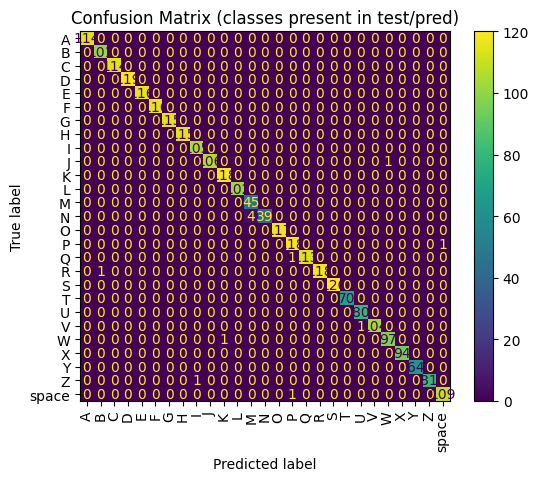

In [33]:
cm_present = confusion_matrix(y_test, y_pred, labels=present_label_ids)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_present, display_labels=present_labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix (classes present in test/pred)")
plt.show()


In [34]:
all_ids = set(range(len(CLASSES)))
used_ids = set(np.unique(y_idx))

missing_ids = sorted(list(all_ids - used_ids))
print("Missing class count:", len(missing_ids))
print("Missing classes:", [CLASSES[i] for i in missing_ids])


Missing class count: 1
Missing classes: ['nothing']


In [35]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print("y_test unique:", len(np.unique(y_test)))
print("y_pred unique:", len(np.unique(y_pred)))


86/86 [==============================] - 0s 3ms/step
y_test unique: 27
y_pred unique: 27


<Figure size 1000x1000 with 0 Axes>

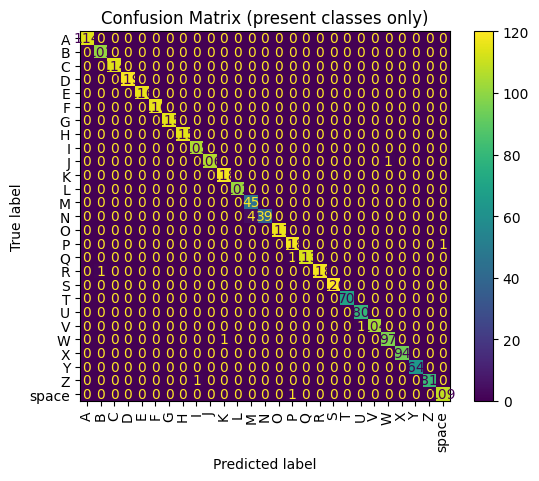

In [36]:
# Use only classes that appear in test or predictions
present_label_ids = np.unique(np.concatenate([y_test, y_pred]))
present_label_ids = np.sort(present_label_ids)

present_labels = [CLASSES[i] for i in present_label_ids]

cm_present = confusion_matrix(y_test, y_pred, labels=present_label_ids)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_present, display_labels=present_labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix (present classes only)")
plt.show()


In [37]:
missing_set = set(missing_ids)
keep_ids = [i for i in range(len(CLASSES)) if i not in missing_set]
CLASSES2 = [CLASSES[i] for i in keep_ids]

# filter X/y_idx to keep only valid classes
mask = np.isin(y_idx, keep_ids)
X2 = X[mask]
y2_old = y_idx[mask]

# remap old ids -> new ids 0..K-1
old_to_new = {old: new for new, old in enumerate(keep_ids)}
y2 = np.array([old_to_new[v] for v in y2_old], dtype=np.int32)

print("Removed classes:", [CLASSES[i] for i in missing_ids])
print("New dataset:", X2.shape, y2.shape, "Num classes:", len(CLASSES2))


Removed classes: ['nothing']
New dataset: (13606, 63) (13606,) Num classes: 27


In [39]:
model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model.save(model_path)

labels_path = os.path.join(MODELS_DIR, "labels.npy")
np.save(labels_path, np.array(CLASSES2))

print("Saved model:", model_path)
print("Saved labels:", labels_path)


Saved model: D:\EDUSign\models\sign_cnn.h5
Saved labels: D:\EDUSign\models\labels.npy


In [40]:
import os
print(os.path.exists(r"D:\EDUSign\models\sign_cnn.h5"), "model exists")
print(os.path.exists(r"D:\EDUSign\models\labels.npy"), "labels exists")


True model exists
True labels exists


In [2]:
import numpy as np


In [5]:
import os

PROJECT_ROOT = r"D:\EDUSign"

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

print("MODELS_DIR:", MODELS_DIR)



MODELS_DIR: D:\EDUSign\models


In [8]:
import numpy as np
import os

dataset_path = os.path.join(DATA_PROCESSED, "landmarks_full_dataset.npz")
data = np.load(dataset_path, allow_pickle=True)

X = data["X"]
y = data["y"]
CLASSES = data["classes"].tolist()

print("Dataset loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", len(CLASSES))


Dataset loaded
X shape: (13606, 63)
y shape: (13606,)
Classes: 28


In [9]:
label_to_index = {label: i for i, label in enumerate(CLASSES)}
y_idx = np.array([label_to_index[label] for label in y], dtype=np.int32)

print("Labels encoded")


Labels encoded


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_idx
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (10884, 63)
Test : (2722, 63)


In [11]:
import tensorflow as tf

model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model = tf.keras.models.load_model(model_path)

print("Model loaded")


Model loaded


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



In [15]:
# ===============================
# 🔁 RESUME PROJECT – CORE IMPORTS
# ===============================

# Standard libraries
import os
import time

# Numerical & plotting
import numpy as np
import matplotlib.pyplot as plt

# Computer vision & ML
import cv2
import mediapipe as mp
import tensorflow as tf

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("All core imports loaded ✅")


All core imports loaded ✅


In [16]:
# ===============================
# 📁 PROJECT PATHS
# ===============================

PROJECT_ROOT = r"D:\EDUSign"

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


PROJECT_ROOT: D:\EDUSign
MODELS_DIR: D:\EDUSign\models
RESULTS_DIR: D:\EDUSign\results


In [2]:
# ===============================
# 📦 LOAD PROCESSED DATASET
# ===============================

dataset_path = os.path.join(DATA_PROCESSED, "landmarks_full_dataset.npz")
data = np.load(dataset_path, allow_pickle=True)

X = data["X"]
y = data["y"]
CLASSES = data["classes"].tolist()

print("Dataset loaded ✅")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", len(CLASSES))


NameError: name 'os' is not defined

In [18]:
# ===============================
# 🔢 LABEL ENCODING
# ===============================

label_to_index = {label: i for i, label in enumerate(CLASSES)}
y_idx = np.array([label_to_index[label] for label in y], dtype=np.int32)

# ===============================
# ✂ TRAIN / TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_idx,
    test_size=0.2,
    random_state=42,
    stratify=y_idx
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (10884, 63)
Test : (2722, 63)


In [19]:
# ===============================
# 🧠 LOAD TRAINED MODEL
# ===============================

model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model = tf.keras.models.load_model(model_path)

print("Model loaded from:", model_path)


Model loaded from: D:\EDUSign\models\sign_cnn.h5


In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import cv2
import mediapipe as mp
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("Imports OK ✅")


Imports OK ✅


In [2]:
PROJECT_ROOT = r"D:\EDUSign"

DATA_RAW = os.path.join(PROJECT_ROOT, "data", "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

for p in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(p, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)


PROJECT_ROOT: D:\EDUSign
RESULTS_DIR: D:\EDUSign\results


In [3]:
dataset_path = os.path.join(DATA_PROCESSED, "landmarks_full_dataset.npz")
data = np.load(dataset_path, allow_pickle=True)

X = data["X"]
y = data["y"]
CLASSES = data["classes"].tolist()

print("Loaded:", dataset_path)
print("X:", X.shape, "y:", y.shape, "classes:", len(CLASSES))


Loaded: D:\EDUSign\data\processed\landmarks_full_dataset.npz
X: (13606, 63) y: (13606,) classes: 28


In [4]:
label_to_index = {label: i for i, label in enumerate(CLASSES)}
y_idx = np.array([label_to_index[label] for label in y], dtype=np.int32)

print("Encoded labels ✅")


Encoded labels ✅


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (10884, 63) (10884,)
Test : (2722, 63) (2722,)


In [6]:
model_path = os.path.join(MODELS_DIR, "sign_cnn.h5")
model = tf.keras.models.load_model(model_path)
print("Loaded model:", model_path)


Loaded model: D:\EDUSign\models\sign_cnn.h5


86/86 [==============================] - 0s 3ms/step


<Figure size 1000x1000 with 0 Axes>

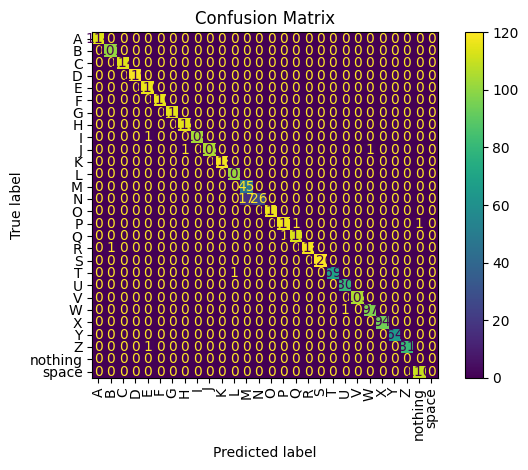

Saved: D:\EDUSign\results\confusion_matrix.png
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       114
           B       0.99      1.00      1.00       101
           C       1.00      1.00      1.00       114
           D       1.00      1.00      1.00       119
           E       0.98      1.00      0.99       116
           F       1.00      1.00      1.00       116
           G       1.00      1.00      1.00       115
           H       0.99      1.00      1.00       115
           I       1.00      0.99      1.00       105
           J       1.00      0.98      0.99       107
           K       1.00      1.00      1.00       118
           L       0.99      1.00      1.00       102
           M       0.73      1.00      0.84        45
           N       1.00      0.60      0.75        43
           O       1.00      1.00      1.00       117
           P       0.99      0.98      0.99       119
           Q       0.99      0.99 

C:\Users\ASUS\anaconda3\envs\sign_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\envs\sign_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\envs\sign_env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\

In [7]:
y_pred = np.argmax(model.predict(X_test), axis=1)

present_ids = np.unique(np.concatenate([y_test, y_pred]))
present_labels = [CLASSES[i] for i in present_ids]

cm = confusion_matrix(y_test, y_pred, labels=present_ids)

disp = ConfusionMatrixDisplay(cm, display_labels=present_labels)
plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation=90, values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(RESULTS_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved:", cm_path)
print(classification_report(y_test, y_pred, target_names=present_labels))


In [8]:
num_classes = len(CLASSES)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(63,)),
    tf.keras.layers.Reshape((63, 1)),
    tf.keras.layers.Conv1D(64, 5, activation="relu"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 5, activation="relu"),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 63, 1)             0         
                                                                 
 conv1d (Conv1D)             (None, 59, 64)            384       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 29, 64)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 25, 128)           41088     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 12, 128)          0         
 1D)                                                             
                                                                 
 flatten (Flatten)           (None, 1536)              0

In [9]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)


Epoch 1/20
137/137 [==============================] - 4s 17ms/step - loss: 2.5845 - accuracy: 0.2512 - val_loss: 1.3103 - val_accuracy: 0.5875
Epoch 2/20
137/137 [==============================] - 2s 15ms/step - loss: 1.0194 - accuracy: 0.6639 - val_loss: 0.5326 - val_accuracy: 0.8438
Epoch 3/20
137/137 [==============================] - 2s 18ms/step - loss: 0.5536 - accuracy: 0.8244 - val_loss: 0.3084 - val_accuracy: 0.9109
Epoch 4/20
137/137 [==============================] - 2s 15ms/step - loss: 0.3590 - accuracy: 0.8904 - val_loss: 0.1907 - val_accuracy: 0.9623
Epoch 5/20
137/137 [==============================] - 2s 16ms/step - loss: 0.2500 - accuracy: 0.9290 - val_loss: 0.1494 - val_accuracy: 0.9633
Epoch 6/20
137/137 [==============================] - 2s 15ms/step - loss: 0.1970 - accuracy: 0.9463 - val_loss: 0.1117 - val_accuracy: 0.9761
Epoch 7/20
137/137 [==============================] - 2s 15ms/step - loss: 0.1568 - accuracy: 0.9585 - val_loss: 0.0764 - val_accuracy: 0.9844

In [2]:
model.save(os.path.join(MODELS_DIR, "sign_cnn.h5"))
np.save(os.path.join(MODELS_DIR, "labels.npy"), np.array(CLASSES))
print("Saved model + labels ✅")


NameError: name 'model' is not defined